# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [277]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#7298ce">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #d18753; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#d18753">**выборы**</font> и подбирать <font color="#d18753">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

<div style="font-size: 40px">ВАЖНО!</div>

Я сейчас стараюсь красиво организовывать notebook, коменты и норм код, пишу Я, а не GPT

In [278]:
!uv add category_encoders polars seaborn numpy matplotlib openpyxl
!uv add openpyxl pyarrow xlrd lxml pyarrow "polars[pandas]"

Resolved 39 packages in 38ms
Audited 37 packages in 19ms
Resolved 39 packages in 6ms
Audited 37 packages in 0.50ms


In [279]:
# IMPORTS:
import polars as pl
import pandas as pd
import seaborn as sns
import numpy as np
import category_encoders as ce

from pathlib import Path
import matplotlib.pyplot as plt

In [280]:
# CONSTANTS:
DATA_DIR = Path("data/")

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [281]:
data_train = pl.read_csv(DATA_DIR / "matches_df_train.csv")
data_test = pl.read_csv(DATA_DIR / "matches_df_test.csv")

In [282]:
print(f"Train: size({data_train.estimated_size("mb"):.3} MB) shape{data_train.shape}")
print(f"Test: size({data_test.estimated_size("mb"):.3} MB) shape{data_test.shape}")

Train: size(32.1 MB) shape(641090, 7)
Test: size(2.51 MB) shape(59748, 5)


In [283]:
dict(data_train.schema)

{'match_id': Int64,
 'date': String,
 'region': String,
 'game_mode': Int64,
 'duration': Int64,
 'radiant_win': Boolean,
 'avg_mmr': Float64}

In [284]:
dict(data_test.schema)

{'match_id': Int64,
 'date': String,
 'region': String,
 'game_mode': Int64,
 'avg_mmr': Float64}

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

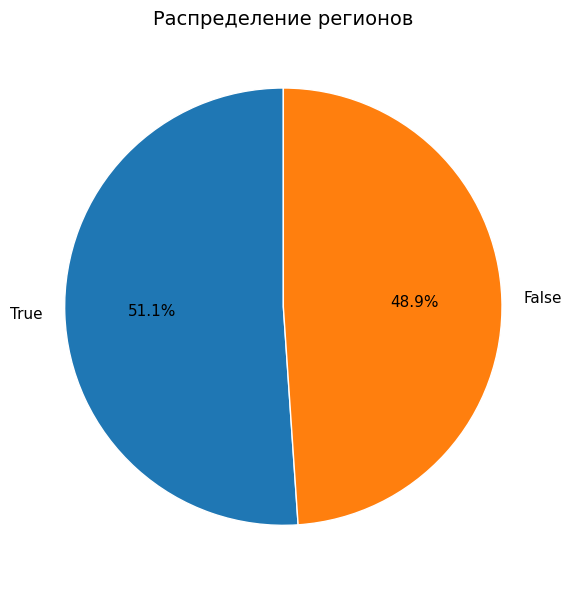

In [285]:
labels, sizes = data_train["radiant_win"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11},
)
plt.title("Распределение регионов", fontsize=14)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** да, подходиь, так как распределенно примерно попалам, поэтому даже самая плохая модель, будет выдавать ~0.5, следовательо Gini будет находиться примерно от 0 до 1
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

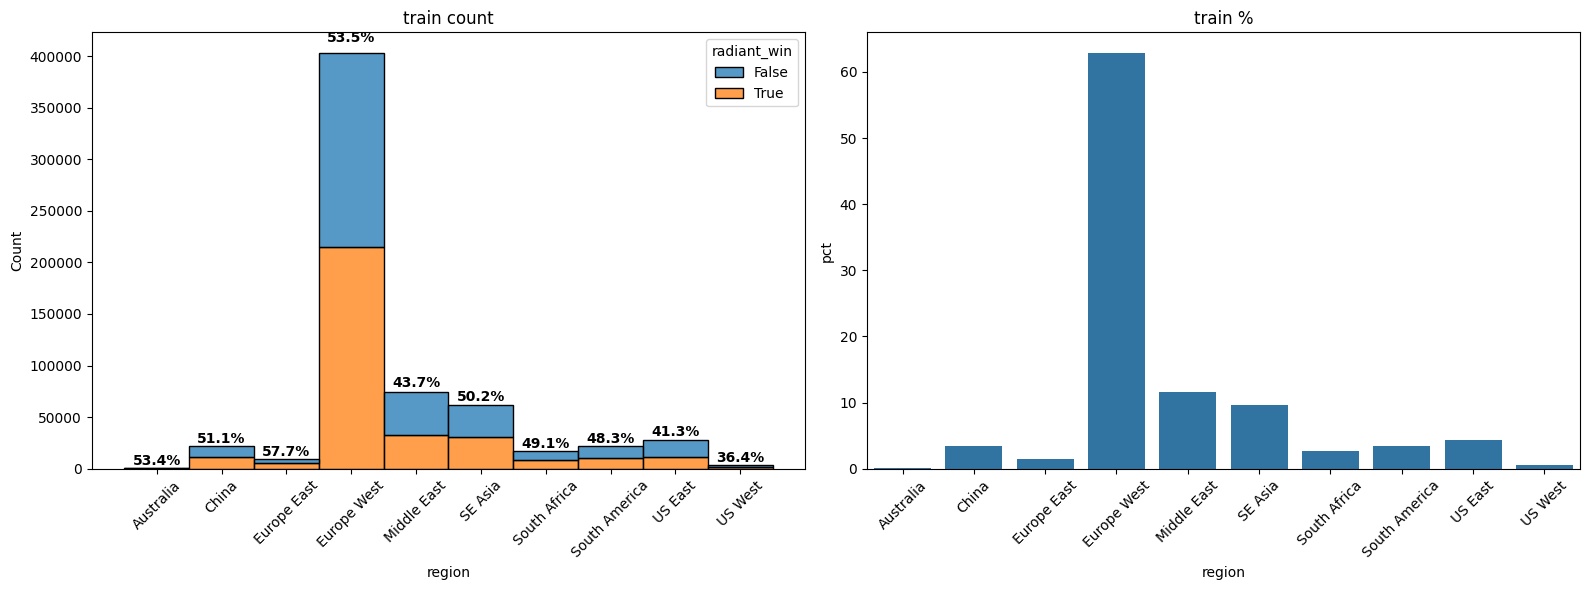

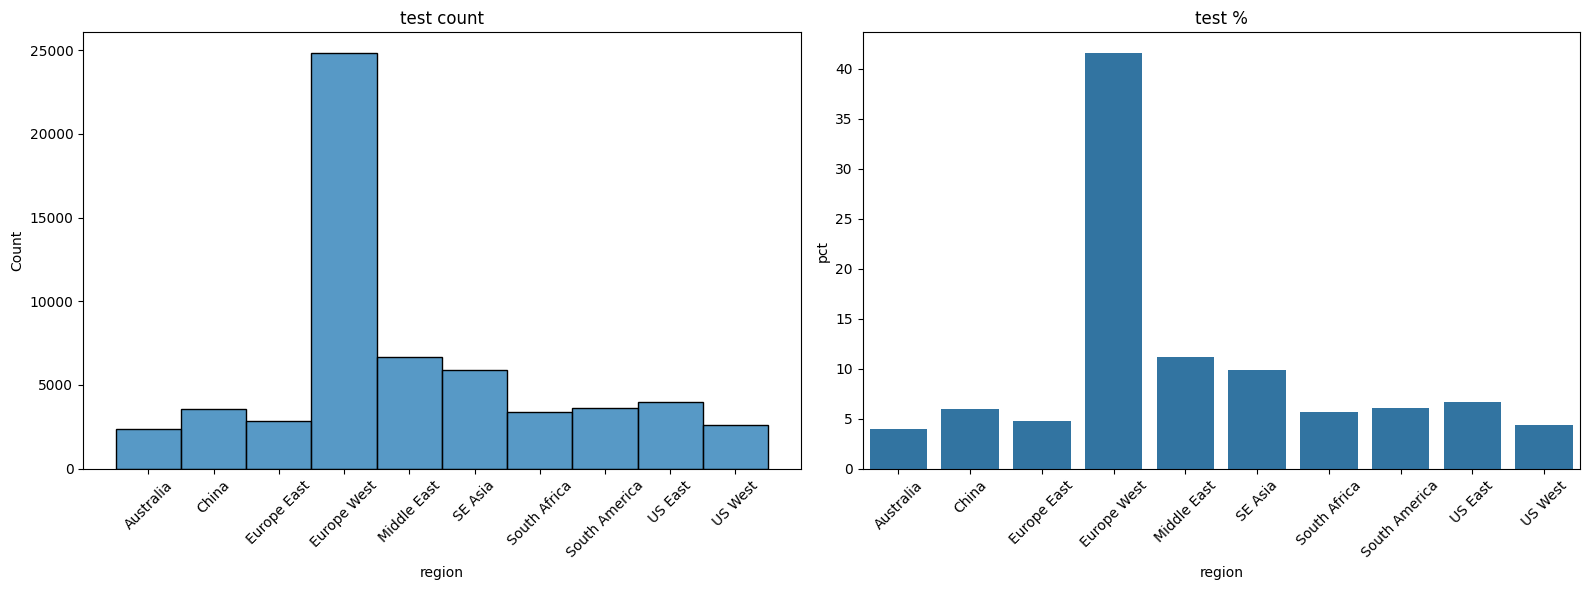

In [286]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


def plots(df: pl.DataFrame, name: str, hue: str | None = None):
    plt.figure(figsize=(16, 6))

    # ---------- 1. Count plot ----------
    ax1 = plt.subplot(1, 2, 1)
    plt.title(name + " count")
    plt.xticks(rotation=45)

    sns.histplot(
        x="region",
        data=df.sort(by="region"),
        hue=hue,
        multiple="stack",
        discrete=True,
        ax=ax1,
    )

    # Если есть hue = radiant_win, подпишем win rate над каждым регионом
    if hue is not None:
        win_rate = (
            df.group_by("region")
            .agg(
                pl.len().alias("count"),
                pl.col(hue).mean().alias("win_rate"),  # если radiant_win это 0/1
            )
            .sort("region")
        )

        for i, row in enumerate(win_rate.iter_rows(named=True)):
            ax1.text(
                i,
                row["count"] + row["count"] * 0.02,
                f'{row["win_rate"] * 100:.1f}%',
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

    # ---------- 2. Percent by region ----------
    ax2 = plt.subplot(1, 2, 2)
    plt.title(name + " %")
    plt.xticks(rotation=45)

    pct_df = (
        df.group_by("region")
        .len()
        .rename({"len": "count"})
        .with_columns(
            (pl.col("count") / pl.col("count").sum() * 100).alias("pct"),
        )
        .sort("region")
    )

    sns.barplot(
        x="region",
        y="pct",
        data=pct_df,
        ax=ax2,
    )

    plt.tight_layout()
    plt.show()


plots(data_train, "train", hue="radiant_win")
plots(data_test, "test")

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:** Да данные несут инсайд о том что Американцы и цетральная европа играет хреново за radiant, но это может быть по причине небольшой выборки для этой группы. 
</div>

Наша первая развилка — <font color="#d18753">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#d18753">**One-Hot Encoder**</font> | <font color="#d18753">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">
Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 
</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Лучше воспользоваться one-hot энкодером, так как таргет хоть и отличается по регионам, но на маленькое значние, поэтому будет сливаться, лучше использовать OHE
</div>

Закодируйте колонку `region` выбранным вами способом

In [287]:
encoded_region_train = data_train.select(pl.col("region")).to_dummies()
data_train = pl.concat(
    [data_train.drop("region"), encoded_region_train], how="horizontal"
)
encoded_region_test = data_test.select(pl.col("region")).to_dummies()
data_test = pl.concat([data_test.drop("region"), encoded_region_test], how="horizontal")

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

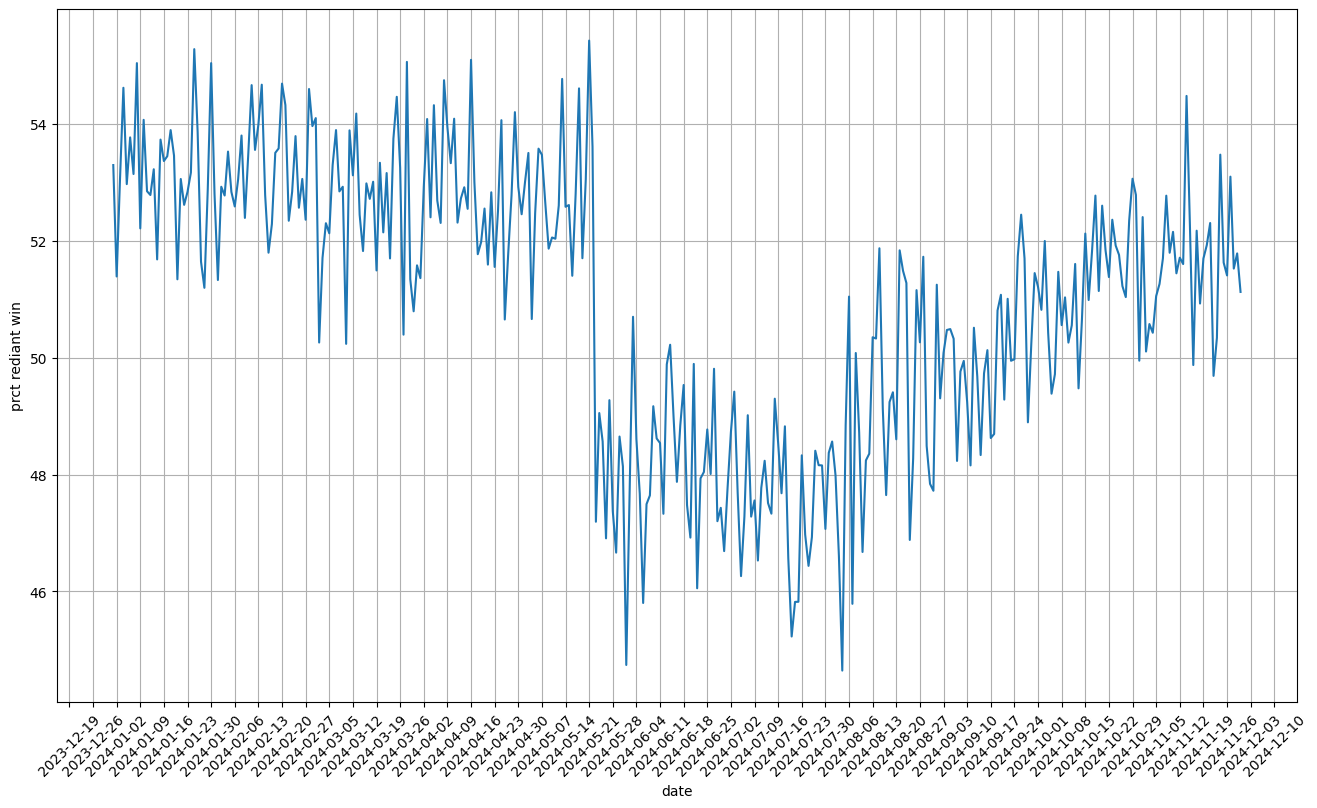

In [288]:
def plot_rediant_win_date(df: pl.DataFrame):
    import matplotlib.dates as mdates

    plt.figure(figsize=(16, 9))
    sns.lineplot(
        y="prct rediant win",
        x="date",
        data=(
            df.lazy()
            .group_by("date")
            .agg((100 * pl.col("radiant_win").mean()).alias("prct rediant win"))
            .collect()
            .cast({"date": pl.Date})
        ),
    )
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45)
    plt.grid(True)


plot_rediant_win_date(data_train)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** 

Я подумал что произошло обновление с изменениями механик, поэтому спросил у perplexity:

- Что изменилось в патче 7.36
- Новые механики карты — Radiant стал уязвимее к агрессивным стратегиям
- Переработка героев — баффы Dire-фаворитов (Pudge, Axe, Underlord)
- Изменения Roshan/Aghanim — упростило фарм для Dire
- Новые нейтралки — баффы предметов для мидера (Radiant страдает)


</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#d18753">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#d18753">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** Да необходимо закадировать дни недели, так как для модели воскресенье будет дальше чем чторник по отношению к понедельнику, хотя разница в днях одинаковая

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [289]:
# 1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
def add_days_and_days_of_week(df: pl.DataFrame) -> pl.DataFrame:

    week_days_encoded = (
        df.lazy()
        .cast({"date": pl.Date})
        .select(pl.col("date").dt.weekday().alias("weekday"))
        .collect()
        .to_dummies()
    )

    return pl.concat(
        [
            (
                df.lazy()
                .cast({"date": pl.Date})
                .with_columns(
                    pl.col("date").dt.day().alias("day"),
                )
                .collect()
            ),
            week_days_encoded,
        ],
        how="horizontal",
    )


data_train = add_days_and_days_of_week(data_train)
data_test = add_days_and_days_of_week(data_test)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Это связано с изменением тренда после обновления (можно увидеть на графике 14.05), потому что это связано исключительно с обновлением и не счем другим

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#d18753">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#d18753">**трешхолд**</font> `t` или <font color="#d18753">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [290]:
# https://habr.com/ru/companies/otus/articles/921604/
from sklearn.model_selection import train_test_split

x = data_train.lazy().drop("radiant_win").collect()
y = data_train.lazy().select("radiant_win").collect()

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3)

In [291]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_auc_score, roc_curve


# NOET: chatpgt построил эти графики
def plot_cv_oot_metrics(
    fold_auc: list[float],
    fold_gini: list[float],
    y: np.ndarray,
    oof_pred: np.ndarray,
):
    valid_mask = ~np.isnan(oof_pred)

    oof_auc = roc_auc_score(y[valid_mask], oof_pred[valid_mask])
    oof_gini = 2 * oof_auc - 1
    fpr, tpr, _ = roc_curve(y[valid_mask], oof_pred[valid_mask])

    folds = np.arange(1, len(fold_auc) + 1)

    # AUC по фолдам
    plt.figure(figsize=(8, 5))
    plt.plot(folds, fold_auc, marker="o")
    plt.axhline(
        np.mean(fold_auc), linestyle="--", label=f"Mean AUC = {np.mean(fold_auc):.4f}"
    )
    plt.xticks(folds)
    plt.xlabel("Fold")
    plt.ylabel("ROC AUC")
    plt.title("ROC AUC by fold")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Gini по фолдам
    plt.figure(figsize=(8, 5))
    plt.plot(folds, fold_gini, marker="o")
    plt.axhline(
        np.mean(fold_gini),
        linestyle="--",
        label=f"Mean Gini = {np.mean(fold_gini):.4f}",
    )
    plt.xticks(folds)
    plt.xlabel("Fold")
    plt.ylabel("Gini")
    plt.title("Gini by fold")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ROC curve по OOF
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, label=f"OOF ROC curve (AUC = {oof_auc:.4f}, Gini = {oof_gini:.4f})"
    )
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("OOF ROC Curve")
    plt.grid(True)
    plt.legend()
    plt.show()


def check_cv_oot_gini(
    x_df: pl.DataFrame, y_df: pl.DataFrame, n_splits: int = 10, plot_: bool = True
):
    splitter = TimeSeriesSplit(n_splits=n_splits)

    x = x_df.to_numpy()
    y = y_df.to_numpy()

    fold_auc = []
    fold_gini = []
    oof_pred = np.full(len(x), np.nan)

    for tri, vali in splitter.split(x):
        x_tr, x_val = x[tri], x[vali]
        y_tr, y_val = y[tri], y[vali]

        model = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    SGDClassifier(
                        loss="log_loss",
                        penalty="l2",
                        alpha=0.0001,
                        max_iter=1000,
                        tol=1e-3,
                        random_state=42,
                    ),
                ),
            ]
        )

        model.fit(x_tr, y_tr)
        yhat = model.predict_proba(x_val)[:, 1]

        auc = roc_auc_score(y_val, yhat)
        gini = 2 * auc - 1

        fold_auc.append(auc)
        fold_gini.append(gini)
        oof_pred[vali] = yhat

    valid_mask = ~np.isnan(oof_pred)
    oof_auc = roc_auc_score(y[valid_mask], oof_pred[valid_mask])
    oof_gini = 2 * oof_auc - 1

    if plot_:
        plot_cv_oot_metrics(fold_auc, fold_gini, y, oof_pred)
        # NOTE: все что ниже (до return) написал gpt

    return {
        "n_features": len(x_df.schema),
        "mean_auc": float(np.mean(fold_auc)),
        "std_auc": float(np.std(fold_auc)),
        "mean_gini": float(np.mean(fold_gini)),
        "std_gini": float(np.std(fold_gini)),
        "oof_auc": float(oof_auc),
        "oof_gini": float(oof_gini),
    }

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#d18753">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#d18753"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#d18753"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#d18753"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#d18753"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#d18753">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#d18753">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#d18753">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но небольшой буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

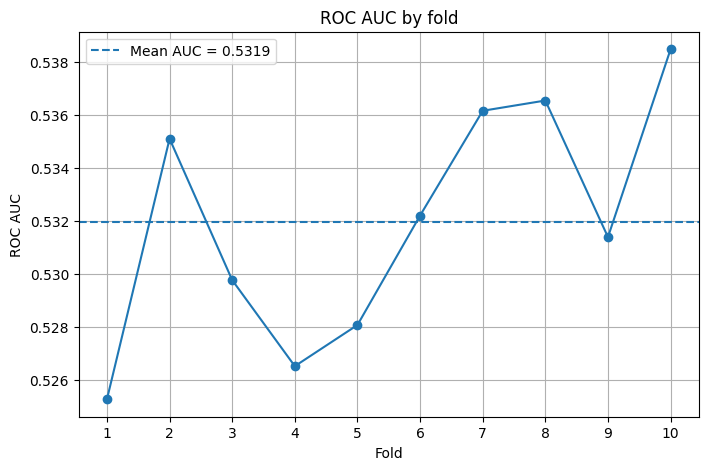

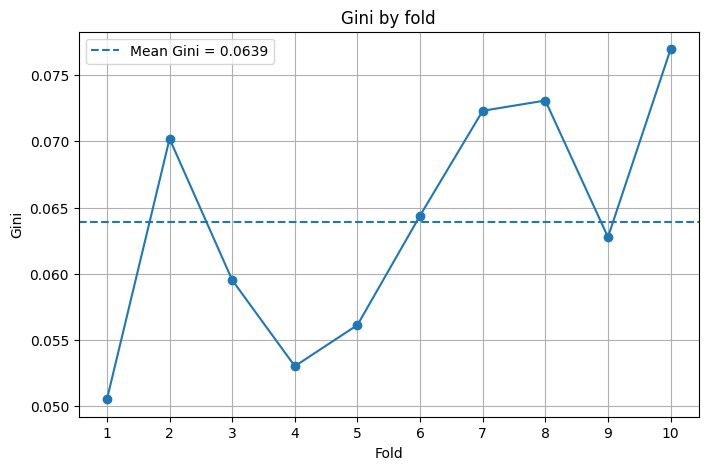

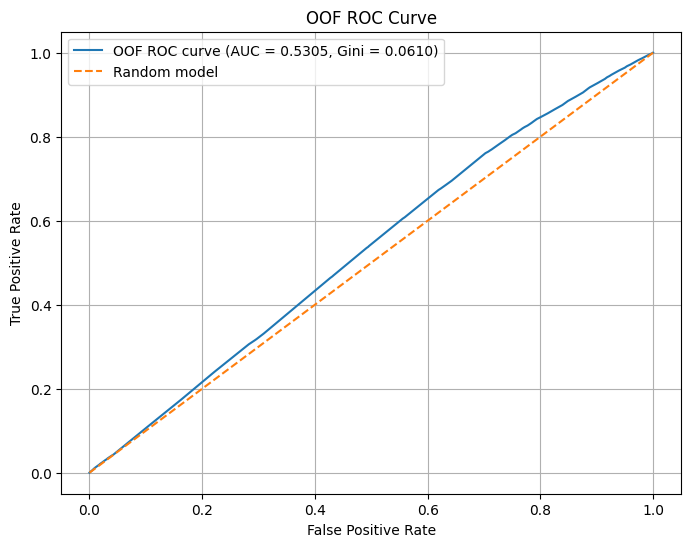

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

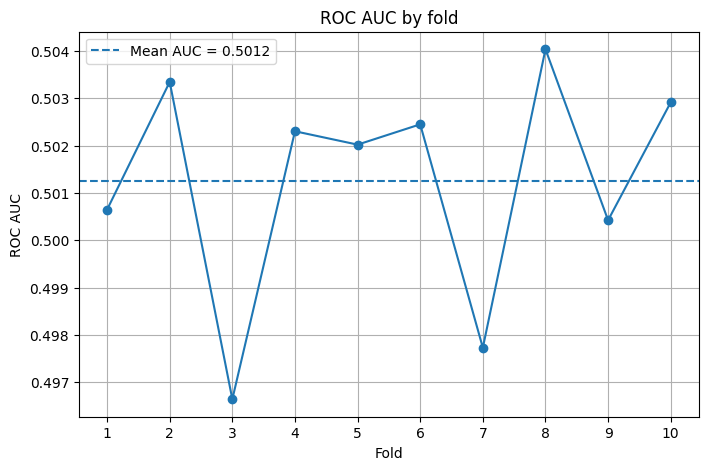

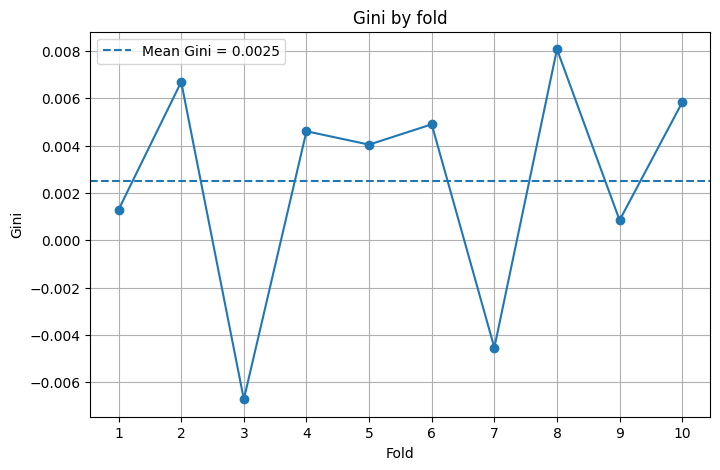

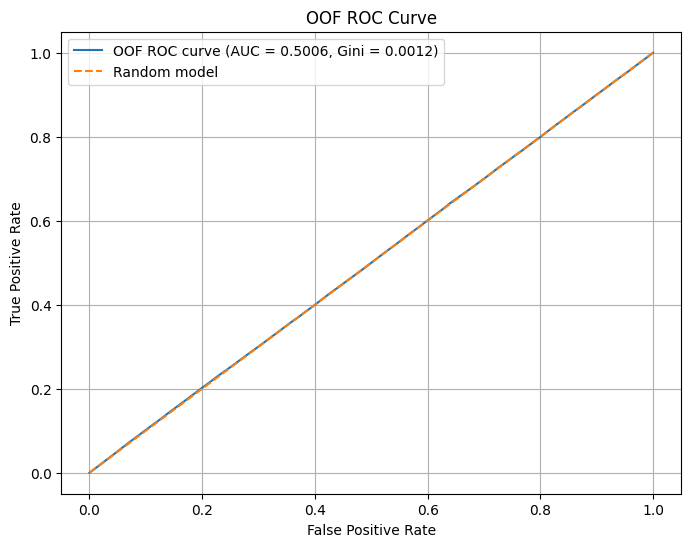

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

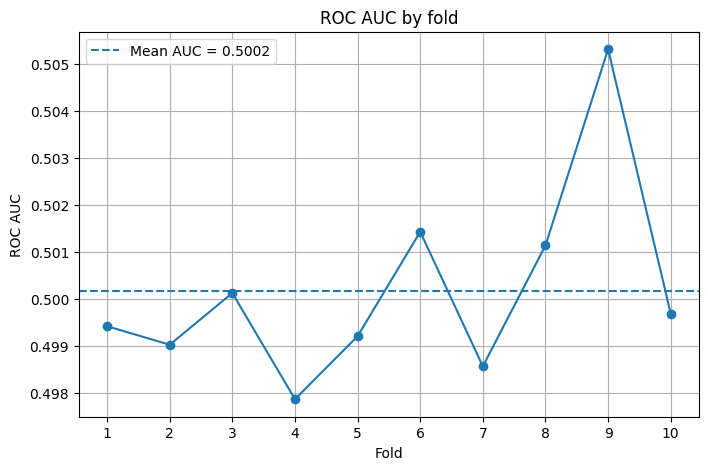

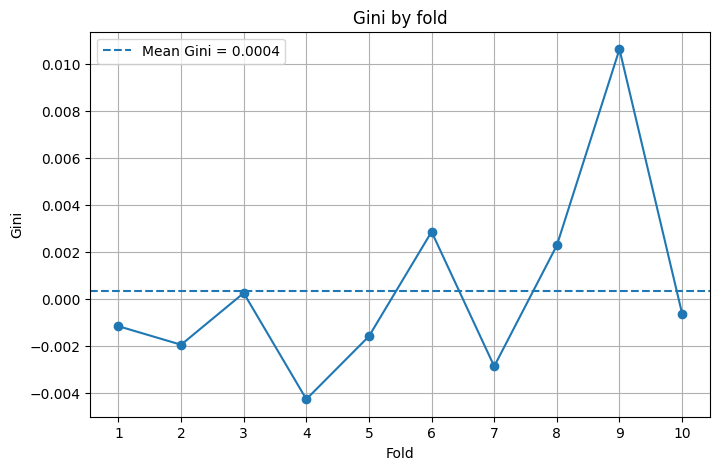

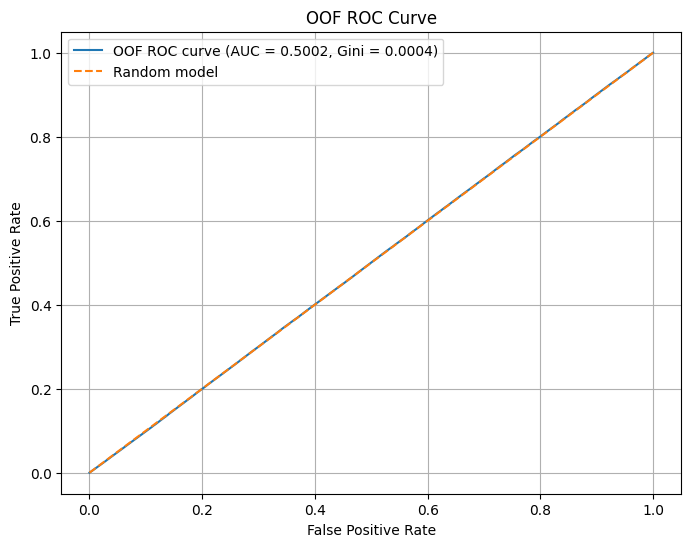

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

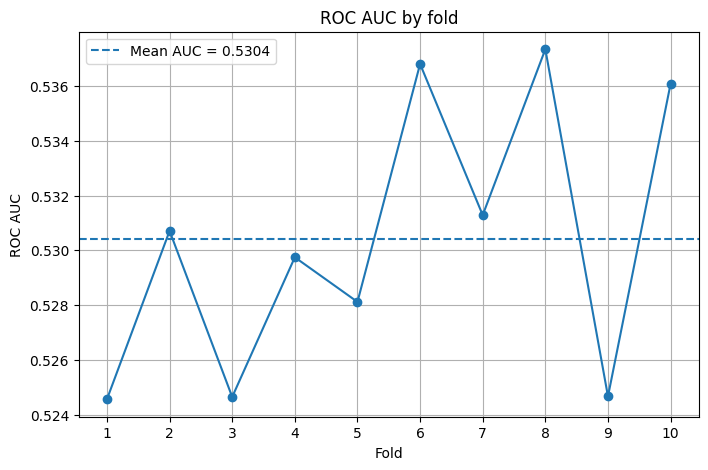

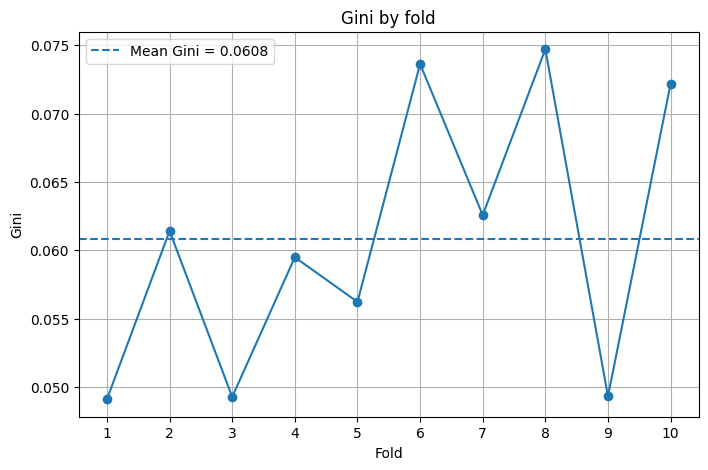

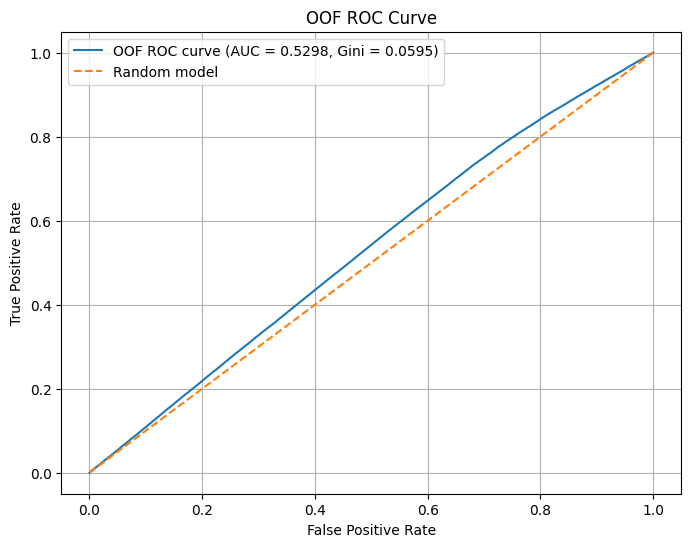

n_features,mean_auc,std_auc,mean_gini,std_gini,oof_auc,oof_gini,name
i64,f64,f64,f64,f64,f64,f64,str
10,0.531948,0.004309,0.063897,0.008618,0.530516,0.061031,"""region"""
18,0.530398,0.004781,0.060796,0.009561,0.529773,0.059547,"""multi"""
7,0.50125,0.002297,0.0025,0.004593,0.500598,0.001196,"""weekend"""
1,0.500182,0.001999,0.000365,0.003999,0.500187,0.000375,"""mathe day"""


In [292]:
import polars.selectors as cs

res_region = check_cv_oot_gini(
    x_train.lazy().select(cs.starts_with("region")).collect(), y_train
)

res_region["name"] = "region"

res_weekday = check_cv_oot_gini(
    x_train.lazy().select(cs.starts_with("weekday")).collect(), y_train
)

res_weekday["name"] = "weekend"

res_monthe_day = check_cv_oot_gini(x_train.lazy().select("day").collect(), y_train)
res_monthe_day["name"] = "mathe day"

res_multi = check_cv_oot_gini(
    x_train.lazy()
    .select(cs.starts_with("region"), cs.starts_with("weekday"), "day")
    .collect(),
    y_train,
)
res_multi["name"] = "multi"

res = pl.concat(
    list(
        map(
            lambda x: pl.DataFrame(x),
            [res_region, res_weekday, res_monthe_day, res_multi],
        )
    )
)
res.sort(by=-pl.col("mean_gini"))

Давайте теперь построим pipline, вспомним последовательность:

- Чтение
- Мы хоть и не убрали null, но это может понадобиться
- Дальше применить OHC к регионам
- Дальше применям StandardScaler для численных перменных
- Как мы поняли даты делают только хуже, но можно попробовать добавить дату новых патчей и обновлений (0/1 есть в данный день обновление или нет)
- Дальше уже модель

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Заметим что средний Джини получился лучше чем при использовании дат и регионов вместе, я уже не говорю о их отдельном использовании. 

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

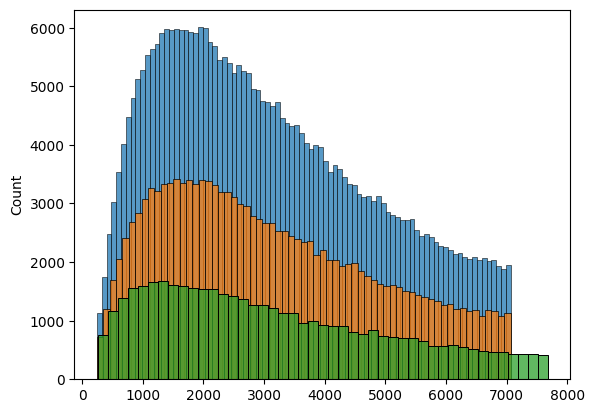

In [293]:
x_test = data_test
scaler = StandardScaler()
for x_df in (x_train, x_val, x_test):
    x_df = x_df["avg_mmr"]
    sns.histplot(x_df)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** похоже на лог нормальное

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но на практике это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

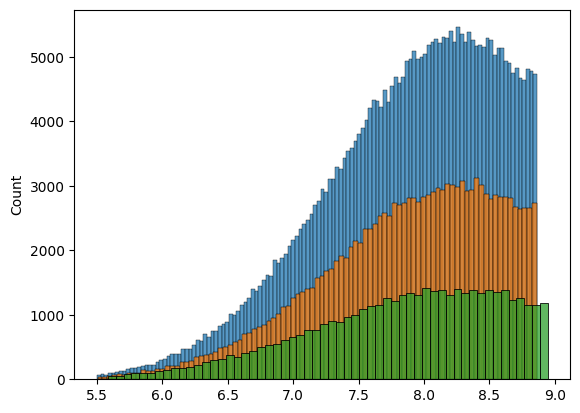

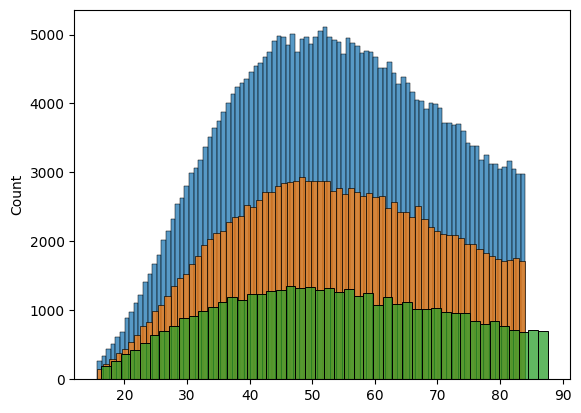

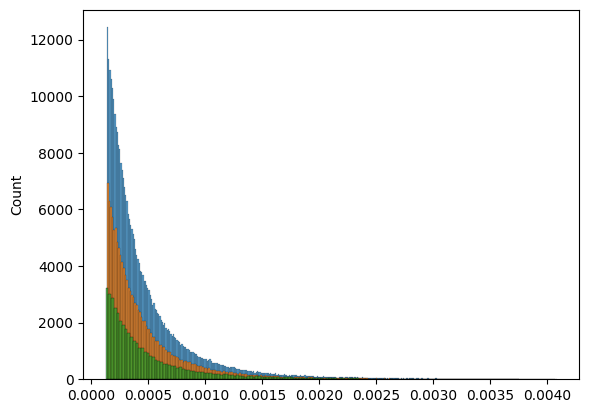

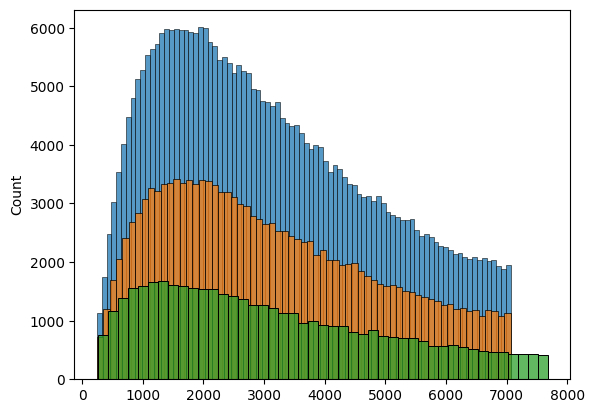

In [294]:
f1 = lambda x: (x + 1).log()
f2 = lambda x: x.sqrt()
f3 = lambda x: 1 / (x + 1)
f4 = lambda x: x.log().exp()


for f in (f1, f2, f3, f4):
    for x_df in (x_train, x_val, x_test):
        x_df = x_df["avg_mmr"]
        sns.histplot(f(x_df))
    plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#d18753">**Можете**</font> замерить его влияние, если есть желание, может это полная дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Можно попробовать заполнить медианой, так как она более устойяива к выборсам, чем средняя, а 0 будет казаться выбрасом, так как полностью занулит импакт от рейдинга и может даже будет занижать важность рейтинга, так как профессианальные игроки практически всегда играют на рейтинг. 

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на тесте

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на тесте \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

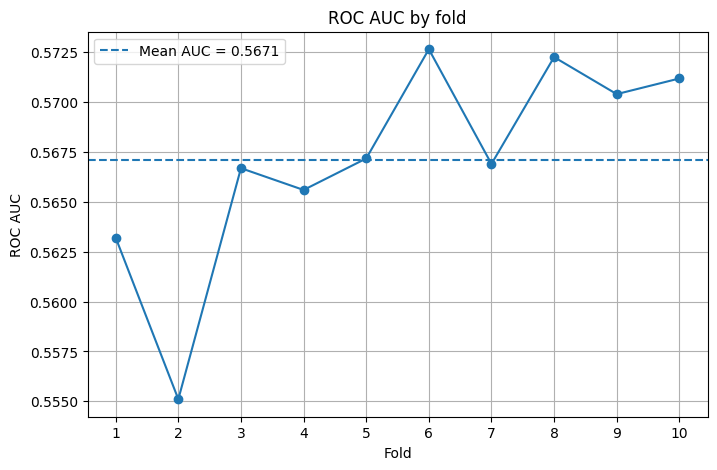

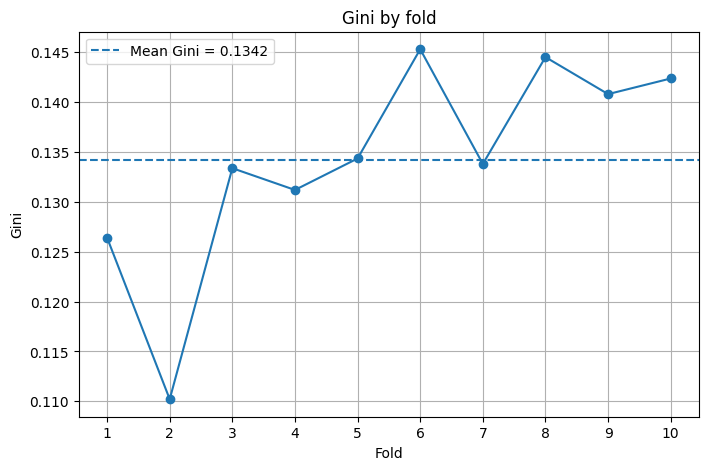

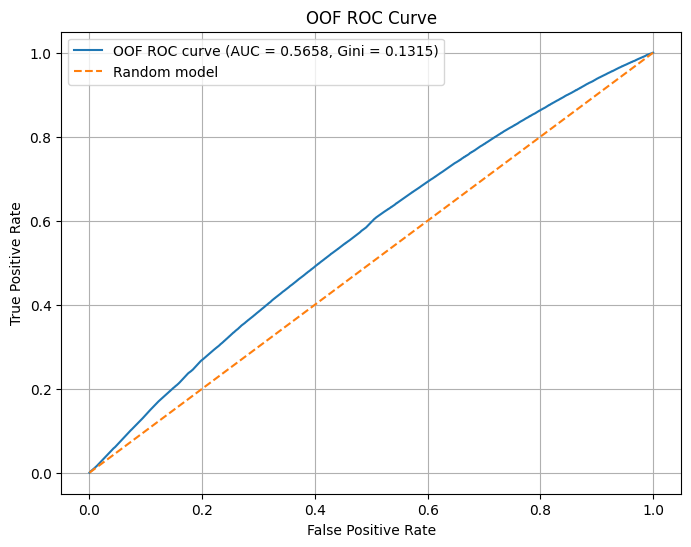

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

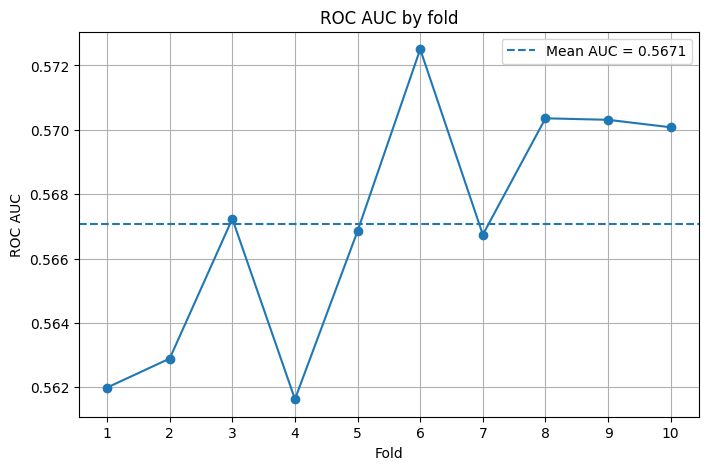

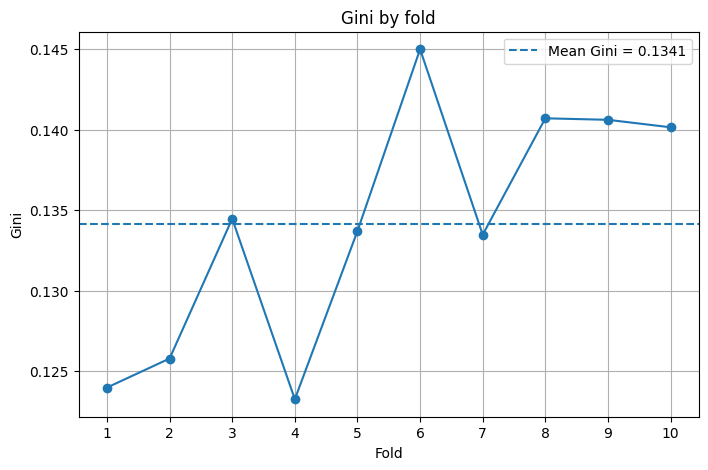

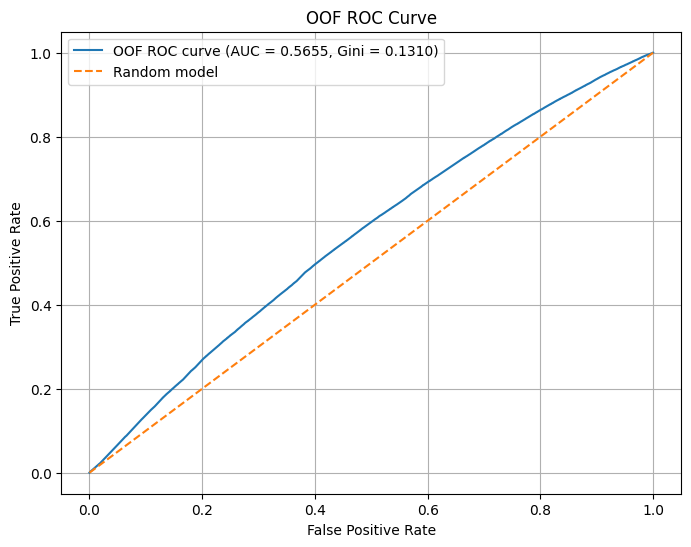

In [295]:
res_nan_0 = check_cv_oot_gini(
    x_df=x_train.lazy()
    .with_columns(
        pl.col("avg_mmr").is_null().alias("mmr_missing"), pl.col("avg_mmr").fill_null(0)
    )
    .select(
        cs.starts_with("region"),
        pl.col("avg_mmr").sqrt().alias("avg_mmr_sqrt"),
        pl.col("mmr_missing"),
    )
    .collect(),
    y_df=y_train,
)
res_nan_0["name"] = "nan -> 0"
res_nan_median = check_cv_oot_gini(
    x_df=x_train.lazy()
    .with_columns(
        pl.col("avg_mmr").is_null().alias("mmr_missing"),
        pl.col("avg_mmr").fill_null(pl.col("avg_mmr").median()),
    )
    .select(
        cs.starts_with("region"),
        pl.col("avg_mmr").sqrt().alias("avg_mmr_sqrt"),
        pl.col("mmr_missing"),
    )
    .collect(),
    y_df=y_train,
)

res_nan_median["name"] = "nan -> median"

In [296]:
pl.concat(list(map(lambda x: pl.DataFrame(x), [res_nan_median, res_nan_0])))

n_features,mean_auc,std_auc,mean_gini,std_gini,oof_auc,oof_gini,name
i64,f64,f64,f64,f64,f64,f64,str
12,0.56706,0.003646,0.134121,0.007292,0.565515,0.13103,"""nan -> median"""
12,0.56711,0.004963,0.13422,0.009927,0.56577,0.131541,"""nan -> 0"""


In [297]:
from numpy import ndarray
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer


# NOTE: gpt помог разобраться как это сделать
class AddMissingIndicator(BaseEstimator, TransformerMixin):
    def __init__(self, column="avg_mmr"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X: pl.DataFrame):
        return (
            X.lazy()
            .with_columns(pl.col("avg_mmr").is_null().alias("mmr_missing"))
            .collect()
        )


preprocessor = ColumnTransformer(
    [
        (
            "region_ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ["region"],
        ),
        (
            "mmr_pipe",
            Pipeline(
                [
                    ("imputer", SimpleImputer(fill_value=0)),
                    (
                        "sqrt",
                        FunctionTransformer(
                            np.sqrt,
                            # NOTE: chatgpt
                            feature_names_out=lambda self, input_features: [
                                f"{col}_sqrt" for col in input_features
                            ],
                        ),
                    ),
                    ("scaler", StandardScaler()),
                ]
            ),
            ["avg_mmr"],
        ),
        (
            "mmr_missing",
            "passthrough",
            ["mmr_missing"],
        ),
    ]
)

pipeline = Pipeline(
    [
        ("add_missing", AddMissingIndicator(column="avg_mmr")),
        ("preprocessor", preprocessor),
        ("model", SGDClassifier(loss="log_loss", random_state=42, alpha=0.001)),
    ]
)

In [298]:
matches_df_train = pl.read_csv(DATA_DIR / "matches_df_train.csv")
matches_df_test = pl.read_csv(DATA_DIR / "matches_df_test.csv")

x_train, x_val, y_train, y_val = train_test_split(
    matches_df_train,
    matches_df_train.lazy().select("radiant_win").collect(),
    test_size=0.2,
)

In [299]:
pipeline.fit(x_train, y_train)

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('add_missing', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,column,'avg_mmr'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('region_ohe', ...), ('mmr_pipe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

In [300]:
y_pred = pipeline.predict_proba(x_val)[:, 1]

In [301]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix


# NOTE: написал chatgpt потому что я задолбался писать эту функцию
def get_main_clf_metrics(y_true: np.ndarray, y_score: np.ndarray, ind: str):
    y_true = y_true.ravel()
    y_score = y_score.ravel()

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

    best_idx = np.argmax(f1)
    best_threshold = thresholds[best_idx]

    y_pred = (y_score >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return pl.DataFrame(
        {
            "ind": ind,
            "roc_auc": roc_auc_score(y_true, y_score),
            "best_threshold": best_threshold,
            "precision": precision[best_idx],
            "recall": recall[best_idx],
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        },
    )


get_main_clf_metrics(y_val.to_numpy(), y_pred, "val")

ind,roc_auc,best_threshold,precision,recall,tp,fp,fn,tn
str,f64,f64,f64,f64,i64,i64,i64,i64
"""val""",0.574347,0.34997,0.51331,0.995124,65313,61926,320,659


Джини лучше при заполнении 0, поэтому оставим 0.

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [302]:
data_const_hero = pl.read_csv(DATA_DIR / "Constants.Heroes.csv")
data_player = pl.read_csv(DATA_DIR / "player_df.csv")

In [303]:
data_player["account_id"].value_counts().sort(by="count", descending=True).head(20)

account_id,count
i64,u32
4294967295,2795673
-1,27267
37619671,801
84244723,763
87266522,761
…,…
186054714,670
86770710,660
89843621,660




Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в Constants.Heroes.csv, то его там не найдёте, потому что это тоже ошибка.

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

Финальным аккордом:

- посмотрите, что за игроки играли на герое с hero_id=0, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты {128, ..., 132}), и за команду сил Света (слоты {0, ..., 4}), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте player_df, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** Я думаю, нет так  как они составляют приличную часть данных

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [304]:
# - посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
data_player = data_player.drop_nulls()
hero_id_match_id = (
    data_player.lazy()
    .filter(pl.col("hero_id") == 0)
    .unique("match_id")
    .collect()["match_id"]
)
data_player = (
    data_player.lazy()
    .filter(~pl.col("match_id").is_in(hero_id_match_id.implode()))
    .collect()
)


# Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них
bad_match_ids = (
    data_player.lazy()
    .group_by("match_id")
    .agg(pl.col("hero_id").n_unique().alias("len"))
    .filter(pl.col("len") != 10)
    .collect()["match_id"]
)

data_player = (
    data_player.lazy()
    .filter(~pl.col("match_id").is_in(bad_match_ids.implode()))
    .collect()
)

# - найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
in_both_teams = (
    data_player.lazy()
    .filter(~pl.col("account_id").is_in([4294967295, -1]))
    .with_columns(
        pl.col("player_slot").is_between(0, 4).alias("is_radiant"),
        pl.col("player_slot").is_between(128, 132).alias("is_dire"),
    )
    .group_by(["match_id", "account_id"])
    .agg((pl.col("is_radiant").any() & pl.col("is_dire").any()).alias("in_both"))
    .filter("in_both")
    .collect()["match_id"]
)
data_player = (
    data_player.lazy()
    .filter(~pl.col("match_id").is_in(in_both_teams.implode()))
    .collect()
)

In [305]:
# - отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
valid_match_ids = (
    data_player.lazy()
    .with_columns(
        pl.col("player_slot").is_between(0, 4).alias("is_radiant"),
        pl.col("player_slot").is_between(128, 132).alias("is_dire"),
    )
    .group_by("match_id")
    .agg(
        pl.col("is_radiant").sum().alias("radiant_count"),
        pl.col("is_dire").sum().alias("dire_count"),
    )
    .filter((pl.col("radiant_count") == 5) & (pl.col("dire_count") == 5))
    .select("match_id")
    .collect()["match_id"]
)

data_player = (
    data_player.lazy()
    .filter(pl.col("match_id").is_in(valid_match_ids.implode()))
    .collect()
)

In [306]:
data_player = (
    data_player.lazy()
    .filter(
        pl.col("match_id").is_in(data_train.unique("match_id")["match_id"].implode())
        | pl.col("match_id").is_in(data_test.unique("match_id")["match_id"].implode())
    )
    .collect()
)

In [398]:
from sklearn.base import BaseEstimator, TransformerMixin


class PlayersCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, test: bool = False):
        self.test = test

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        x = X
        hero_id_match_id = (
            x.lazy()
            .filter(pl.col("hero_id") == 0)
            .unique("match_id")
            .collect()["match_id"]
        )

        x = (
            x.lazy()
            .filter(~pl.col("match_id").is_in(hero_id_match_id.implode()))
            .collect()
        )

        # найдите, есть ли игры, в которых это по какой-то причине не так. если таких матчей не слишком много, избавьтесь от них

        bad_match_ids = (
            x.lazy()
            .group_by("match_id")
            .agg(pl.col("hero_id").n_unique().alias("len"))
            .filter(pl.col("len") != 10)
            .collect()["match_id"]
        )

        x = (
            x.lazy()
            .filter(~pl.col("match_id").is_in(bad_match_ids.implode()))
            .collect()
        )

        # - найдите игроков, которые в одном матче играли одновременно и за команду сил тьмы (слоты `{128, ..., 132}`), и за команду сил света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
        in_both_teams = (
            x.lazy()
            .filter(~pl.col("account_id").is_in([4294967295, -1]))
            .with_columns(
                pl.col("player_slot").is_between(0, 4).alias("is_radiant"),
                pl.col("player_slot").is_between(128, 132).alias("is_dire"),
            )
            .group_by(["match_id", "account_id"])
            .agg(
                (pl.col("is_radiant").any() & pl.col("is_dire").any()).alias("in_both")
            )
            .filter("in_both")
            .collect()["match_id"]
        )
        x = (
            x.lazy()
            .filter(~pl.col("match_id").is_in(in_both_teams.implode()))
            .collect()
        )

        return x

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#d18753">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#d18753">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [308]:
from scipy.sparse import csr_array  # вам может понравиться


class HeroesEncoder:

    def fit(self, X, y=None):
        pass

    def transform(self, X: pl.DataFrame):
        encoded_hero = X.lazy().select("hero_id").collect().to_dummies()
        ret = (
            pl.concat(
                [X.lazy().drop("hero_id").collect(), encoded_hero], how="horizontal"
            )
            .lazy()
            .with_columns(
                cs.starts_with("hero_id").cast(pl.Int8)
                * (
                    pl.when(pl.col("player_slot").is_between(0, 4))
                    .then(1)
                    .otherwise(-1)
                )
            )
            .group_by("match_id")
            .agg(cs.starts_with("hero_id").sum())
            .collect()
        )

        return ret

In [309]:
def pivot_player_with_match(df_matchc: pl.DataFrame, df_player: pl.DataFrame):
    on_columns = list(dict(df_player.schema).keys())
    on_columns.remove("player_slot")
    on_columns.remove("match_id")
    on_columns.remove("account_id")
    on_columns.remove("hero_id")

    return (
        df_matchc.lazy()
        .join(df_player.lazy(), on="match_id")
        .with_columns(pl.col("player_slot").cast(pl.String))
        .pivot(
            "player_slot",
            index="match_id",
            on_columns=df_player.unique("player_slot")["player_slot"]
            .sort()
            .cast(pl.String),
            values=on_columns,
        )
        .collect()
    )


pivot_player_with_match(matches_df_train, data_player)

match_id,kills_0,kills_1,kills_2,kills_3,kills_4,kills_128,kills_129,kills_130,kills_131,kills_132,deaths_0,deaths_1,deaths_2,deaths_3,deaths_4,deaths_128,deaths_129,deaths_130,deaths_131,deaths_132,assists_0,assists_1,assists_2,assists_3,assists_4,assists_128,assists_129,assists_130,assists_131,assists_132,gold_0,gold_1,gold_2,gold_3,gold_4,gold_128,…,gold_per_min_3,gold_per_min_4,gold_per_min_128,gold_per_min_129,gold_per_min_130,gold_per_min_131,gold_per_min_132,xp_per_min_0,xp_per_min_1,xp_per_min_2,xp_per_min_3,xp_per_min_4,xp_per_min_128,xp_per_min_129,xp_per_min_130,xp_per_min_131,xp_per_min_132,hero_damage_0,hero_damage_1,hero_damage_2,hero_damage_3,hero_damage_4,hero_damage_128,hero_damage_129,hero_damage_130,hero_damage_131,hero_damage_132,tower_damage_0,tower_damage_1,tower_damage_2,tower_damage_3,tower_damage_4,tower_damage_128,tower_damage_129,tower_damage_130,tower_damage_131,tower_damage_132
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
665108,8.0,0.0,13.0,14.0,1.0,2.0,13.0,4.0,7.0,7.0,11.0,4.0,10.0,4.0,5.0,11.0,4.0,7.0,9.0,5.0,7.0,9.0,7.0,12.0,6.0,13.0,15.0,18.0,12.0,8.0,814.0,3495.0,2894.0,4129.0,2954.0,836.0,…,739.0,265.0,271.0,437.0,402.0,291.0,367.0,452.0,312.0,492.0,750.0,263.0,307.0,522.0,468.0,329.0,458.0,10340.0,2777.0,14532.0,30047.0,1868.0,3992.0,19201.0,12046.0,6954.0,6895.0,4140.0,1393.0,1708.0,6359.0,483.0,70.0,216.0,332.0,109.0,415.0
748365,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1.0,1.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,629.0,783.0,423.0,283.0,164.0,2.0,…,315.0,146.0,292.0,180.0,100.0,237.0,367.0,251.0,300.0,213.0,466.0,174.0,173.0,165.0,54.0,301.0,105.0,1823.0,3121.0,350.0,2022.0,1698.0,1771.0,877.0,921.0,1088.0,72.0,0.0,0.0,64.0,0.0,77.0,0.0,0.0,0.0,0.0,0.0
107388,1.0,13.0,1.0,3.0,4.0,2.0,12.0,20.0,4.0,7.0,10.0,9.0,5.0,13.0,9.0,9.0,4.0,1.0,5.0,5.0,13.0,5.0,4.0,7.0,9.0,9.0,19.0,5.0,15.0,3.0,50.0,760.0,323.0,89.0,1704.0,974.0,…,207.0,277.0,305.0,470.0,820.0,352.0,528.0,384.0,544.0,462.0,277.0,401.0,332.0,644.0,908.0,465.0,604.0,8764.0,16493.0,4622.0,6591.0,6082.0,3190.0,19566.0,18830.0,6747.0,8128.0,8.0,22.0,199.0,41.0,44.0,590.0,1166.0,6423.0,584.0,3061.0
17724,5.0,10.0,4.0,6.0,15.0,3.0,5.0,7.0,0.0,1.0,5.0,3.0,2.0,4.0,3.0,9.0,9.0,10.0,5.0,7.0,16.0,10.0,11.0,13.0,12.0,6.0,3.0,5.0,8.0,1.0,602.0,3885.0,1311.0,268.0,1126.0,216.0,…,293.0,562.0,327.0,417.0,262.0,162.0,428.0,681.0,577.0,722.0,398.0,787.0,372.0,497.0,382.0,186.0,542.0,15285.0,8557.0,11910.0,7681.0,16809.0,7022.0,11833.0,11144.0,6075.0,2552.0,3007.0,189.0,6620.0,83.0,1721.0,239.0,155.0,16.0,33.0,372.0
252489,4.0,1.0,4.0,1.0,3.0,7.0,8.0,0.0,14.0,2.0,2.0,7.0,7.0,10.0,5.0,4.0,1.0,6.0,1.0,2.0,4.0,3.0,2.0,4.0,5.0,10.0,2.0,7.0,6.0,4.0,1361.0,72.0,1629.0,1208.0,501.0,141.0,…,170.0,239.0,424.0,537.0,235.0,539.0,270.0,386.0,311.0,345.0,217.0,275.0,491.0,516.0,202.0,585.0,290.0,5913.0,3264.0,6567.0,6581.0,6771.0,17852.0,6294.0,5328.0,18092.0,2606.0,119.0,19.0,0.0,26.0,0.0,2366.0,4721.0,536.0,1217.0,550.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
193994,5.0,5.0,3.0,6.0,3.0,11.0,9.0,7.0,12.0,4.0,9.0,11.0,8.0,10.0,7.0,4.0,2.0,7.0,6.0,4.0,4.0,9.0,4.0,5.0,11.0,12.0,19.0,16.0,14.0,19.0,148.0,992.0,415.0,1896.0,772.0,3846.0,…,289.0,267.0,478.0,451.0,280.0,429.0,317.0,525.0,361.0,275.0,358.0,373.0,684.0,592.0,360.0,532.0,444.0,8639.0,12404.0,9218.0,9779.0,7773.0,9880.0,16511.0,12313.0,11201.0,7202.0,379.0,55.0,740.0,160.0,338.0,2964.0,3167.0,435.0,1477.0,629.0
265800,5.0,5.0,3.0,8.0,25.0,13.0,11.0,1.0,3.0,18.0,7.0,10.0,12.0,8.0,10.0,10.0,10.0,9.0,11.0,6.0,15.0,13.0,22.0,11.0,10.0,22.0,14.0,12.0,26.0,18.0,2135.0,1531.0,2168.0,1525.0,1492.0,3190.0,…,370.0,620.0,378.0

In [ ]:
def compare_data(
    df_match: pl.DataFrame,
    df_player: pl.DataFrame,
    df_heroes: pl.DataFrame | None = None,
):
    df_player = PlayersCleaner().transform(df_player)
    transformed_data_player = HeroesEncoder().transform(df_player)

    return (
        df_match.lazy()
        .join(transformed_data_player.lazy(), on="match_id", how="inner")
        .collect()
    )

In [396]:
ls = [x for x in removed]
data_player.lazy().filter(pl.col("match_id").is_in(removed)).collect().write_csv(
    "removed.csv"
)

In [311]:
from numpy import ndarray
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

preprocessor = ColumnTransformer(
    [
        (
            "region_ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ["region"],
        ),
        (
            "mmr_pipe",
            Pipeline(
                [
                    ("imputer", SimpleImputer(fill_value=0)),
                    (
                        "sqrt",
                        FunctionTransformer(
                            np.sqrt,
                            # NOTE: chatgpt
                            feature_names_out=lambda self, input_features: [
                                f"{col}_sqrt" for col in input_features
                            ],
                        ),
                    ),
                    ("scaler", StandardScaler()),
                ]
            ),
            ["avg_mmr"],
        ),
    ],
    remainder="passthrough",
)

pipeline = Pipeline(
    [
        ("add_missing", AddMissingIndicator(column="avg_mmr")),
        ("preprocessor", preprocessor),
        ("model", SGDClassifier(loss="log_loss")),
    ]
)

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [312]:
matches_df_train = pl.read_csv(DATA_DIR / "matches_df_train.csv")
data_player = pl.read_csv(DATA_DIR / "player_df.csv")
constants_heroes = pl.read_csv(DATA_DIR / "Constants.Heroes.csv")

In [313]:
comp_df_train = compare_data(matches_df_train, data_player)

In [329]:
from sklearn.model_selection import train_test_split

y = comp_df_train.lazy().select("radiant_win").collect()
x = (
    comp_df_train.lazy()
    .drop(["match_id", "date", "game_mode", "duration", "radiant_win"])
    .collect()
)
print(x.schema)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5)

Schema({'region': String, 'avg_mmr': Float64, 'hero_id_1': Int64, 'hero_id_10': Int64, 'hero_id_100': Int64, 'hero_id_101': Int64, 'hero_id_102': Int64, 'hero_id_103': Int64, 'hero_id_104': Int64, 'hero_id_105': Int64, 'hero_id_106': Int64, 'hero_id_107': Int64, 'hero_id_109': Int64, 'hero_id_11': Int64, 'hero_id_110': Int64, 'hero_id_111': Int64, 'hero_id_112': Int64, 'hero_id_12': Int64, 'hero_id_13': Int64, 'hero_id_14': Int64, 'hero_id_15': Int64, 'hero_id_16': Int64, 'hero_id_17': Int64, 'hero_id_18': Int64, 'hero_id_19': Int64, 'hero_id_2': Int64, 'hero_id_20': Int64, 'hero_id_21': Int64, 'hero_id_22': Int64, 'hero_id_23': Int64, 'hero_id_25': Int64, 'hero_id_26': Int64, 'hero_id_27': Int64, 'hero_id_28': Int64, 'hero_id_29': Int64, 'hero_id_3': Int64, 'hero_id_30': Int64, 'hero_id_31': Int64, 'hero_id_32': Int64, 'hero_id_33': Int64, 'hero_id_34': Int64, 'hero_id_35': Int64, 'hero_id_36': Int64, 'hero_id_37': Int64, 'hero_id_38': Int64, 'hero_id_39': Int64, 'hero_id_4': Int64, '

In [330]:
pipeline.fit(x_train, y_train)

/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('add_missing', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,column,'avg_mmr'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('region_ohe', ...), ('mmr_pipe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0

In [331]:
y_pred_val = pipeline.predict_proba(x_val)[:, 1]
score_roc_auc = roc_auc_score(y_val, y_pred_val)
get_main_clf_metrics(y_val.to_numpy(), y_pred_val, "predicted")

ind,roc_auc,best_threshold,precision,recall,tp,fp,fn,tn
str,f64,f64,f64,f64,i64,i64,i64,i64
"""predicted""",0.650334,0.348271,0.540625,0.93479,45958,39051,3206,7790


In [332]:
2 * score_roc_auc - 1

0.30066715309178926

Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняет данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#d18753">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать их со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. \
<font color="#d18753">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#d18753"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \
Выбор, как всегда, в ваших руках.

</div>

In [318]:
!pip3 install optuna


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [319]:
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    # model parameters
    params = {
        "alpha": trial.suggest_float("alpha", 1e-6, 1e1, log=True),
        "loss": trial.suggest_categorical(
            "loss", ["log_loss", "hinge", "modified_huber"]
        ),
        "max_iter": trial.suggest_int("max_iter", 300, 3000),
    }

    pipeline = Pipeline(
        [
            ("add_missing", AddMissingIndicator(column="avg_mmr")),
            ("preprocessor", preprocessor),
            ("model", SGDClassifier(**params)),
        ]
    )
    score = cross_val_score(
        pipeline, x_val, y_val, cv=5, scoring="roc_auc", n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-09 21:56:50,722] A new study created in memory with name: no-name-72de7fd7-9961-4040-b616-6208359fcaad
  0%|          | 0/25 [00:00<?, ?it/s]/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ra

[I 2026-03-09 21:56:55,690] Trial 0 finished with value: 0.6349289385493154 and parameters: {'alpha': 2.9167904552586785e-05, 'loss': 'hinge', 'max_iter': 792}. Best is trial 0 with value: 0.6349289385493154.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:01,385] Trial 1 finished with value: 0.6140137090322456 and parameters: {'alpha': 4.749660555095266e-06, 'loss': 'hinge', 'max_iter': 2860}. Best is trial 0 with value: 0.6349289385493154.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:03,058] Trial 2 finished with value: 0.6488205025049295 and parameters: {'alpha': 0.0019253179172213216, 'loss': 'log_loss', 'max_iter': 1129}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:04,810] Trial 3 finished with value: 0.5921259243132979 and parameters: {'alpha': 1.8344964540175734, 'loss': 'hinge', 'max_iter': 1899}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:06,292] Trial 4 finished with value: 0.6473289800675528 and parameters: {'alpha': 0.06795074893761203, 'loss': 'modified_huber', 'max_iter': 828}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:07,770] Trial 5 finished with value: 0.6483448609773335 and parameters: {'alpha': 0.0011571730301882994, 'loss': 'hinge', 'max_iter': 367}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:09,257] Trial 6 finished with value: 0.6485149947417297 and parameters: {'alpha': 0.02281456110917466, 'loss': 'modified_huber', 'max_iter': 2851}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:10,858] Trial 7 finished with value: 0.6454373434785454 and parameters: {'alpha': 0.00026017591058842446, 'loss': 'log_loss', 'max_iter': 1309}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:13,529] Trial 8 finished with value: 0.6269970233953327 and parameters: {'alpha': 1.7454180204795336e-05, 'loss': 'log_loss', 'max_iter': 917}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:14,928] Trial 9 finished with value: 0.5961156274920738 and parameters: {'alpha': 0.26736384663796303, 'loss': 'hinge', 'max_iter': 477}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:16,552] Trial 10 finished with value: 0.5873136874887022 and parameters: {'alpha': 8.213595112263102, 'loss': 'log_loss', 'max_iter': 1954}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:17,965] Trial 11 finished with value: 0.648350637716169 and parameters: {'alpha': 0.010040616129539472, 'loss': 'modified_huber', 'max_iter': 2984}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:19,504] Trial 12 finished with value: 0.6484938771225984 and parameters: {'alpha': 0.011551422975870208, 'loss': 'modified_huber', 'max_iter': 2530}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:21,620] Trial 13 finished with value: 0.6403197826660258 and parameters: {'alpha': 0.00037217640504719337, 'loss': 'modified_huber', 'max_iter': 1440}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:23,121] Trial 14 finished with value: 0.6304105248962234 and parameters: {'alpha': 0.07413296276653457, 'loss': 'log_loss', 'max_iter': 2333}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:24,772] Trial 15 finished with value: 0.6484774872575905 and parameters: {'alpha': 0.009298826863062657, 'loss': 'modified_huber', 'max_iter': 1207}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:26,398] Trial 16 finished with value: 0.6481850719180045 and parameters: {'alpha': 0.0013139253488274932, 'loss': 'log_loss', 'max_iter': 1732}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:29,871] Trial 17 finished with value: 0.6305885646842889 and parameters: {'alpha': 0.00010774708894173875, 'loss': 'modified_huber', 'max_iter': 2472}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:31,337] Trial 18 finished with value: 0.6074328955533935 and parameters: {'alpha': 0.3620009977293144, 'loss': 'log_loss', 'max_iter': 2170}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:45,565] Trial 19 finished with value: 0.5634846025899309 and parameters: {'alpha': 1.6469231114557505e-06, 'loss': 'modified_huber', 'max_iter': 1585}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:47,082] Trial 20 finished with value: 0.6389457652316576 and parameters: {'alpha': 0.03611269434463063, 'loss': 'log_loss', 'max_iter': 1081}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:48,521] Trial 21 finished with value: 0.6479512059269807 and parameters: {'alpha': 0.006552436249362208, 'loss': 'modified_huber', 'max_iter': 2720}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:50,282] Trial 22 finished with value: 0.6457186560219826 and parameters: {'alpha': 0.001870969924122809, 'loss': 'modified_huber', 'max_iter': 2619}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:51,883] Trial 23 finished with value: 0.6479850003637416 and parameters: {'alpha': 0.04547781596679619, 'loss': 'modified_huber', 'max_iter': 2195}. Best is trial 2 with value: 0.6488205025049295.


/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/gorsenkovegor/.rye/py/cpython@3.12.3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataC

[I 2026-03-09 21:57:53,546] Trial 24 finished with value: 0.64870014990027 and parameters: {'alpha': 0.019851344370389174, 'loss': 'modified_huber', 'max_iter': 2579}. Best is trial 2 with value: 0.6488205025049295.


In [320]:
print(study.best_params)
print(2 * study.best_value - 1)

{'alpha': 0.0019253179172213216, 'loss': 'log_loss', 'max_iter': 1129}
0.297641005009859


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [324]:
from optuna.visualization import (
    plot_param_importances,
)

plot_param_importances(study)

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [442]:
data_test = pl.read_csv(DATA_DIR / "matches_df_test.csv")
x_main_test = compare_data(data_test, data_player)
x = x_main_test.lazy().drop(["match_id", "date", "game_mode"]).collect()

In [443]:
res_pred = pl.concat(
    [
        x_main_test.select("match_id"),
        pl.DataFrame({"radiant_win": (pipeline.predict_proba(x)[:, 1] - 0.34997)}),
    ],
    how="horizontal",
)

In [467]:
data_test = pl.read_csv(DATA_DIR / "matches_df_test.csv")
final = (
    data_test.join(res_pred, on="match_id", how="left")
    .fill_null(0)
    .select(
        pl.col("match_id").cast(pl.Int64).cast(pl.String).alias("ID"),
        pl.col("radiant_win").alias("Value"),
    )
)

In [465]:
final.write_csv("result.csv")

In [473]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)


def plot_roc_pr(y_true, y_score, title="Model quality"):
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()

    # ROC / Gini
    auc = roc_auc_score(y_true, y_score)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}, Gini = {gini:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title}: ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}: Precision-Recall")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "auc": auc,
        "gini": gini,
        "average_precision": ap,
    }

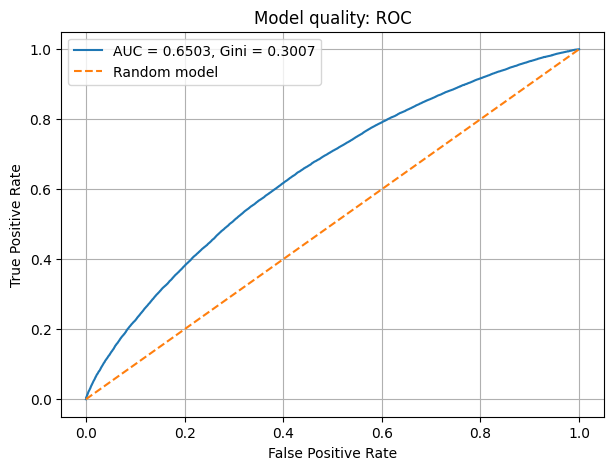

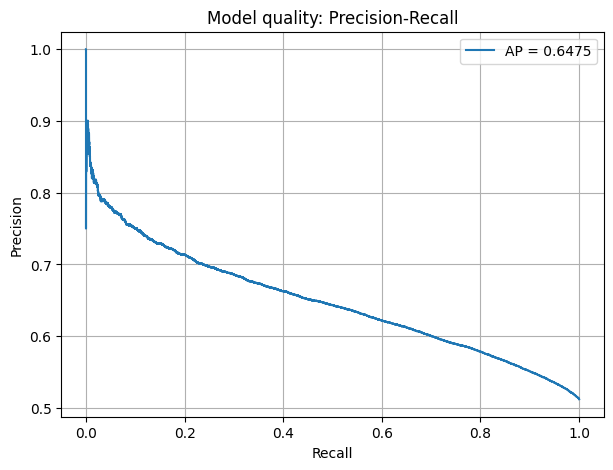

{'auc': 0.6503335765458946,
 'gini': 0.30066715309178926,
 'average_precision': 0.6475368662788041}

In [474]:
pred = pipeline.predict_proba(x_val)[:, 1]
plot_roc_pr(y_val, pred)